In [23]:
import xarray as xr
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pypalettes import load_cmap

import functions.eddy_feedback as ef

# Import various EFP data

In [24]:
daily_path = '/home/links/ct715/eddy_feedback/chapter1/efp_random/data/daily_efp_8models.csv'

day = pd.read_csv(daily_path, index_col=0)

In [25]:
mixed_path = '/home/links/ct715/eddy_feedback/chapter1/efp_random/data/non-regridded_efp_AWI-fabricated.csv'

mix = pd.read_csv(mixed_path, index_col=0)

### Match subset of models

In [26]:
mix_subset = mix[mix['model'].isin(day['model'].unique())].sort_values(by='model').reset_index(drop=True)
mix_subset

,model,efp_nh,efp_sh
0,AWI-CM-1-1-MR,0.3724,0.4354
1,CNRM-CM6-1,0.2421,0.2082
2,CanESM5,0.4256,0.4618
3,FGOALS-f3-L,0.2354,0.1274
4,HadGEM3-GC31-LL,0.2730,0.2951
5,HadGEM3-GC31-MM,0.3137,0.3002
6,IPSL-CM6A-LR,0.2719,0.1959
7,MIROC6,0.2213,0.3253


In [27]:
# Example: assume your dfs are called day, mix, mix_subset
# Add a column to identify which dataframe they came from
day['dataset'] = 'daily-efp'
mix_subset['dataset'] = 'mixed-efp (8 models)'
mix['dataset'] = 'mixed-efp (all models)'


# Concatenate them
df_all = pd.concat([day, mix_subset, mix], ignore_index=True)

# Melt to long format for seaborn
df_melt = df_all.melt(id_vars=['model', 'dataset'], 
                      value_vars=['efp_nh', 'efp_sh'],
                      var_name='hemisphere',
                      value_name='efp')


---

# Reanalysis error bars

In [30]:
import pandas as pd
import numpy as np

BOOTSTRAP_CSV = '/home/links/ct715/eddy_feedback/chapter1/daily_efp/bootstrap/data/reanalysis/efp_full/jra55_efp_bootstrap_summary_efp_full.csv'

_csv = pd.read_csv(BOOTSTRAP_CSV)

FREQ_SEASON_TO_LABEL = {
    ('6h',    'DJF'): 'EFP_nh_6h',
    ('6h',    'JAS'): 'EFP_sh_6h',
    ('daily', 'DJF'): 'EFP_nh_daily',
    ('daily', 'JAS'): 'EFP_sh_daily',
}

records = []
for (freq, season), label in FREQ_SEASON_TO_LABEL.items():
    case = f'1979_2016_{freq}_div1_QG'
    row  = _csv[(_csv['case'] == case) & (_csv['season'] == season)]
    if row.empty:
        print(f"Warning: no bootstrap data for {case} {season}")
        continue
    mean, std = row['efp_mean'].values[0], row['efp_std'].values[0]
    records.append({'efp_type': label, 'efp_mean': mean, 'efp_std': std})
    print(f"{label} ({case}): {mean:.3f}  [{mean - std:.3f}, {mean + std:.3f}]")

bootstrap_df = pd.DataFrame(records)
bootstrap_df

EFP_nh_6h (1979_2016_6h_div1_QG): 0.409  [0.357, 0.462]
EFP_sh_6h (1979_2016_6h_div1_QG): 0.337  [0.301, 0.373]
EFP_nh_daily (1979_2016_daily_div1_QG): 0.357  [0.306, 0.407]
EFP_sh_daily (1979_2016_daily_div1_QG): 0.219  [0.188, 0.251]


,efp_type,efp_mean,efp_std
0,EFP_nh_6h,0.409401,0.052243
1,EFP_sh_6h,0.336804,0.035887
2,EFP_nh_daily,0.356805,0.050328
3,EFP_sh_daily,0.219424,0.031819


# Paper plot

In [31]:
df_melt

,model,dataset,hemisphere,efp
0,AWI-CM-1-1-MR,daily-efp,efp_nh,0.2592
1,CNRM-CM6-1,daily-efp,efp_nh,0.2244
2,CanESM5,daily-efp,efp_nh,0.3133
3,FGOALS-f3-L,daily-efp,efp_nh,0.2353
4,HadGEM3-GC31-LL,daily-efp,efp_nh,0.1735
...,...,...,...,...
57,IPSL-CM6A-LR,mixed-efp (all models),efp_sh,0.1959
58,MIROC6,mixed-efp (all models),efp_sh,0.3253
59,NorESM2-LM,mixed-efp (all models),efp_sh,0.3754
60,OpenIFS-159,mixed-efp (all models),efp_sh,0.3283


/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


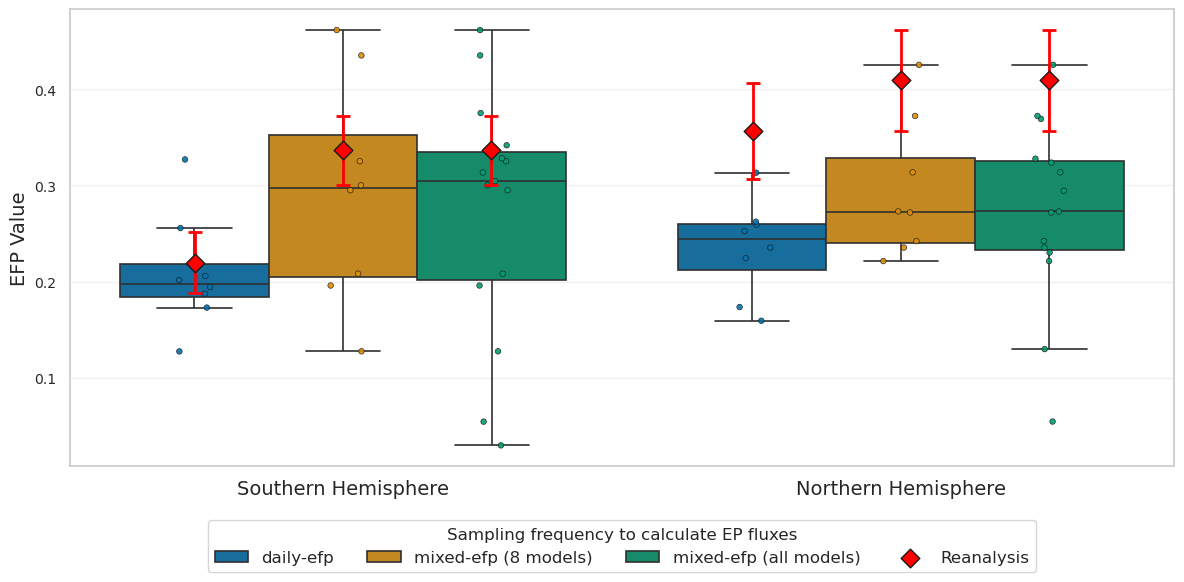

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette='colorblind', style='whitegrid')

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Get the unique hemisphere values from your data
hemisphere_order = df_melt['hemisphere'].unique()
# Reverse the order
hemisphere_order = hemisphere_order[::-1]

# Boxplot with reversed order
sns.boxplot(
    data=df_melt,
    x='hemisphere', y='efp', hue='dataset',
    order=hemisphere_order,
    linewidth=1.2, showfliers=False,
    ax=ax
)

# Overlay stripplot to show individual model values
sns.stripplot(
    data=df_melt,
    x='hemisphere', y='efp', hue='dataset',
    order=hemisphere_order,
    dodge=True, alpha=0.9, size=4, jitter=True,
    marker="o", linewidth=0.5, edgecolor='k',
    ax=ax
)

# --- Helper functions to pull from bootstrap_df ---
def _mean(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_mean'].values[0]

def _std(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_std'].values[0]

# --- Add custom points with error bars ---
points = {
    ("NH", "daily-mean"): _mean('EFP_nh_daily'),
    ("NH", "sub-daily"):  _mean('EFP_nh_6h'),
    ("NH", "sub-daily8"): _mean('EFP_nh_6h'),
    ("SH", "daily-mean"): _mean('EFP_sh_daily'),
    ("SH", "sub-daily"):  _mean('EFP_sh_6h'),
    ("SH", "sub-daily8"): _mean('EFP_sh_6h'),
}

std_errors = {
    ("NH", "daily-mean"): _std('EFP_nh_daily'),
    ("NH", "sub-daily"):  _std('EFP_nh_6h'),
    ("NH", "sub-daily8"): _std('EFP_nh_6h'),
    ("SH", "daily-mean"): _std('EFP_sh_daily'),
    ("SH", "sub-daily"):  _std('EFP_sh_6h'),
    ("SH", "sub-daily8"): _std('EFP_sh_6h'),
}

# Updated positions: SH at 0, NH at 1
positions = {
    ("SH", "daily-mean"): -0.265,
    ("SH", "sub-daily"):  0.0,
    ("SH", "sub-daily8"):  0.265,
    ("NH", "daily-mean"):  0.735,
    ("NH", "sub-daily"):  1.0,
    ("NH", "sub-daily8"):  1.265,
}

for (hemi, dataset), value in points.items():
    x = positions[(hemi, dataset)]
    yerr = std_errors[(hemi, dataset)]
    ax.errorbar(x, value, yerr=yerr,
                color='red', linewidth=2, capsize=5, capthick=2, zorder=10)
    ax.scatter(x, value, color='red', s=90, edgecolor='k', zorder=11, marker='D')

# --- Labels and styling ---
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("EFP Value", fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Southern Hemisphere", "Northern Hemisphere"])
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

# --- Custom legend ---
handles, labels = ax.get_legend_handles_labels()
unique_handles = handles[0:3]
unique_labels = labels[0:3]
diamond_handle = plt.scatter([], [], color='red', edgecolor='k', marker='D', s=90, label='Reanalysis')
unique_handles.append(diamond_handle)
unique_labels.append('Reanalysis')

ax.legend(unique_handles, unique_labels,
          title="Sampling frequency to calculate EP fluxes",
          loc="lower center",
          bbox_to_anchor=(0.5, -0.25),
          ncol=4, fontsize=12, title_fontsize=12,
          frameon=True)

plt.tight_layout()
# plt.savefig('./plots/efp_bw_spread_reanalysis.png', dpi=300)
plt.show()

# Non-boxplot version

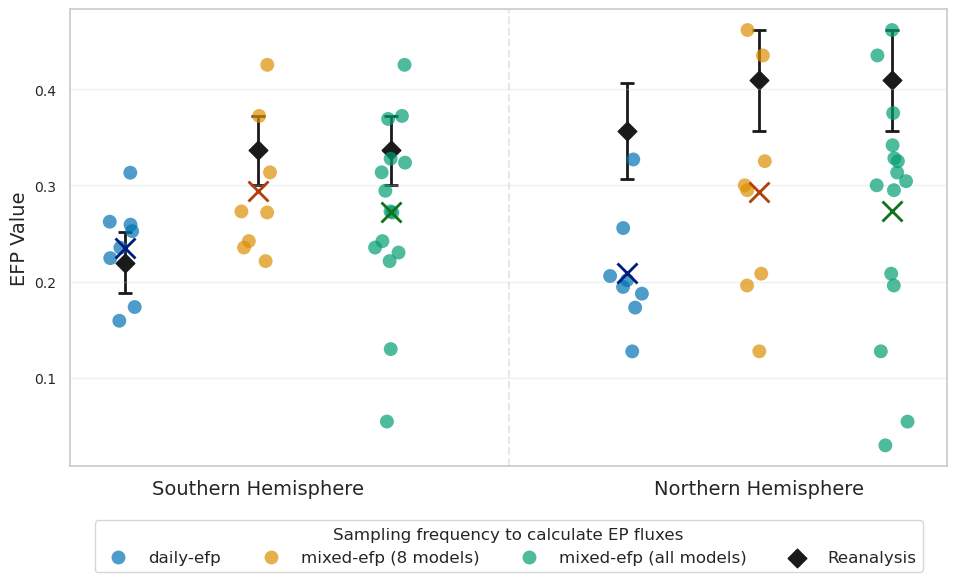

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette='colorblind', style='whitegrid')

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Get the unique hemisphere values from your data
hemisphere_order = df_melt['hemisphere'].unique()
# Reverse the order
hemisphere_order = hemisphere_order[::-1]

sns.stripplot(
    data=df_melt,
    x='hemisphere', y='efp', hue='dataset',
    dodge=True, alpha=0.7,
    size=10, zorder=1,
    ax=ax
)
sns.pointplot(
    data=df_melt,
    x='hemisphere', y='efp', hue='dataset',
    errorbar=None,
    dodge=0.265*2,
    markers='x', markersize=15,
    palette='dark',
    ax=ax,
    linestyle="none"
)

# --- Helper functions to pull from bootstrap_df ---
def _mean(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_mean'].values[0]

def _std(efp_type):
    return bootstrap_df[bootstrap_df['efp_type'] == efp_type]['efp_std'].values[0]

# --- Add custom points with error bars ---
points = {
    ("NH", "daily-mean"): _mean('EFP_nh_daily'),
    ("NH", "sub-daily"):  _mean('EFP_nh_6h'),
    ("NH", "sub-daily8"): _mean('EFP_nh_6h'),
    ("SH", "daily-mean"): _mean('EFP_sh_daily'),
    ("SH", "sub-daily"):  _mean('EFP_sh_6h'),
    ("SH", "sub-daily8"): _mean('EFP_sh_6h'),
}

std_errors = {
    ("NH", "daily-mean"): _std('EFP_nh_daily'),
    ("NH", "sub-daily"):  _std('EFP_nh_6h'),
    ("NH", "sub-daily8"): _std('EFP_nh_6h'),
    ("SH", "daily-mean"): _std('EFP_sh_daily'),
    ("SH", "sub-daily"):  _std('EFP_sh_6h'),
    ("SH", "sub-daily8"): _std('EFP_sh_6h'),
}

# Updated positions: SH at 0, NH at 1
positions = {
    ("SH", "daily-mean"): -0.265,
    ("SH", "sub-daily"):  0.0,
    ("SH", "sub-daily8"):  0.265,
    ("NH", "daily-mean"):  0.735,
    ("NH", "sub-daily"):  1.0,
    ("NH", "sub-daily8"):  1.265,
}

for (hemi, dataset), value in points.items():
    x = positions[(hemi, dataset)]
    yerr = std_errors[(hemi, dataset)]
    ax.errorbar(x, value, yerr=yerr,
                color='k', linewidth=2, capsize=5, capthick=2, zorder=-2)
    ax.scatter(x, value, color='k', s=90, edgecolor='k', zorder=-1, marker='D')

# --- Draw a vertical line between the hemispheres ---
ax.axvline(x=0.5, color='lightgray', linestyle='--', linewidth=1.5, zorder=0, alpha=0.5)

# --- Labels and styling ---
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("EFP Value", fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Southern Hemisphere", "Northern Hemisphere"])
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)

# --- Custom legend ---
handles, labels = ax.get_legend_handles_labels()
unique_handles = handles[0:3]
unique_labels = labels[0:3]
diamond_handle = plt.scatter([], [], color='k', edgecolor='k', marker='D', s=90, label='Reanalysis')
unique_handles.append(diamond_handle)
unique_labels.append('Reanalysis')

ax.legend(unique_handles, unique_labels,
          title="Sampling frequency to calculate EP fluxes",
          loc="lower center",
          bbox_to_anchor=(0.5, -0.25),
          ncol=4, fontsize=12, title_fontsize=12,
          frameon=True)

plt.tight_layout()
# plt.savefig('./plots/efp_bw_spread_reanalysis.png', dpi=300)
plt.show()